## Setup Libraries

In [1]:
import torch
import os, sys
import numpy as np, random
import pandas as pd

from colorama import Fore, Style
import matplotlib.pyplot as plt
import seaborn as sns
import gc

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 100)

# np.random.seed(42)
# random.seed(42)
# torch.manual_seed(42)

In [2]:
## -- Machine Learning --
import catboost as cgb

from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

## Load Data

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
orig = pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Orig shape :", orig.shape)

train

Train shape: (668665, 15)
Test shape : (286571, 14)
Orig shape : (10000, 15)


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,668660,30,71090.0,27.4,2,5,6,5.0,Male,Urban,Sedan,No,Yes,Medium,No
668661,668661,32,129990.0,5.0,2,5,4,1.0,Female,Suburban,SUV,Yes,Yes,Low,No
668662,668662,64,121791.0,24.2,1,5,6,1.0,Female,Suburban,Hatchback,Yes,Yes,Low,No
668663,668663,51,115923.0,43.7,2,0,0,1.0,Female,Rural,SUV,Yes,Yes,Low,No


## Preprocess Features

In [4]:
%%time

ID = 'id'
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Annual_Income_USD', 'Range_Anxiety_Level'),
    ('Age', 'Range_Anxiety_Level'),
    ('Annual_Income_USD', 'Income_/_100_floor_'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype(str)#'category'

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
    df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype(str)#'category'
    df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype(str)#'category'
    df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype(str)#'category'
    df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype(str)#'category'

    # Categorize numericals
    for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype(str) # 'category'

    # Digit extraction
    for col in ['Daily_Commute_km']:
        decimal_name = f"_{col}_decimal"
        df[decimal_name] = (df[col] % 1).round(2).astype('float32')
    df['Annual_Income_USD_is_multiple_10_'] = (
        np.floor(df['Annual_Income_USD']) % 10 == 0
    ).astype(str) # 'category'

    # Target encoding from orig
    for col in ['Annual_Income_USD']:
        orig_enc_name = f"_{col}_mean_target_orig"
        df[orig_enc_name] = (
            df[col]
            .map(orig.groupby(col)[TARGET].mean())
            .fillna(orig[TARGET].mean())
            .astype('float32')
        )

    # Count encoding
    for col in ['Annual_Income_USD']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

    # Discretize numericals
    bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype(str) # 'category'

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype(str)#'category'

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X

X      init shape: (668665, 13)
X_test init shape: (286571, 13) 

init len(cat_cols): 6
init len(num_cols): 7 

len(new_cat_cols): 18
len(new_num_cols): 4 

prep len(cat_cols): 24
prep len(num_cols): 11 

X      prep shape: (668665, 35)
X_test prep shape: (286571, 35) 

CPU times: user 8.95 s, sys: 872 ms, total: 9.83 s
Wall time: 9.83 s


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197


In [5]:
[c for c in cat_cols if c in combo_names]

['Annual_Income_USD_Range_Anxiety_Level_',
 'Age_Range_Anxiety_Level_',
 'Annual_Income_USD_Income_/_100_floor__']

## Config

In [6]:
# --- CATBOOST MODEL ---
bayes_params = {
    'boosting_type': 'Plain',
    'grow_policy': 'SymmetricTree',
    'bootstrap_type': 'Bayesian',
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': 0.1,
    # 'l2_leaf_reg': 1.0,
    # 'depth': 4,
    # ---------------------------------
    'bagging_temperature': 0.5,
    # 'random_strength': 0.8,
    # ---------------------------------
    'verbose': 0,
    'random_state': 101,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

bern_params = {
    'boosting_type': "Plain",
    'grow_policy': "Depthwise",
    'bootstrap_type': "Bernoulli",
    # ---------------------------------
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': 0.1,
    # 'l2_leaf_reg': 5.0,
    # 'depth': 8,
    # ---------------------------------
    # 'subsample': 0.8, # auto 0.66
    # 'colsample_bylevel': 0.7,
    'min_data_in_leaf': 30,
    # ---------------------------------
    'verbose': 0,
    'random_state': 102,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

loss_params = {
    'boosting_type': "Plain",
    'grow_policy': "Lossguide",
    # ---------------------------------
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': 0.1,
    # 'l2_leaf_reg': 1.0,
    # 'depth': 6,
    # ---------------------------------
    'max_leaves': 32,
    'min_data_in_leaf': 20,
    # ---------------------------------
    'verbose': 0,
    'random_state': 103,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

ord_params = {
    'boosting_type': "Ordered",
    'grow_policy': "SymmetricTree",
    'bootstrap_type': "Bayesian",
    # ---------------------------------
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'learning_rate': 0.1,
    # 'l2_leaf_reg': 1.0,
    # 'depth': 8,
    # ---------------------------------
    'bagging_temperature': 0.5,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'verbose': 0,
    'random_state': 104,
    'thread_count': -1,
    'allow_writing_files': False,
    'task_type': "GPU" if torch.cuda.is_available() else "CPU",
}

print("Parameters defined!")

Parameters defined!


In [7]:
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(
    pd.concat([X, y], axis=1),
    train_size=300_000,
    stratify=y,
    random_state=9,
)
train_X = pd.concat([X, y], axis=1).copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

train_X

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1,0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2,1
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3,0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094,0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160,0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836,0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197,0


## Train K-Fold

In [8]:
%%time

MODEL_NAME = 'CATlos_mlp'

USE_TE       = True
DROP_TE_COLS = True

if not USE_TE:
    DROP_TE_COLS = False

FOLDS  = 10
LR     = 0.04

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

X_1 = train_X.drop([TARGET], axis=1)
y_1 = train_X[TARGET].astype(int)

oof_preds = np.zeros(len(X_1))
test_preds = np.zeros(len(X_test))

fold_scores = []
feat_importances = []

print(f"\n 🚀 Training {MODEL_NAME} with {FOLDS } folds **********\n")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    X_tr, X_val = X_1.iloc[tr_idx], X_1.iloc[val_idx]
    y_tr, y_val = y_1.iloc[tr_idx], y_1.iloc[val_idx]
    X_tst = X_test.copy()  

    # Target encoding
    if USE_TE:
        te_cols = combo_names
        print(f"  ⧗ Target encoding ({len(te_cols)}) features")
        TE = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
        tr_enc = TE.fit_transform(X_tr[te_cols], y_tr)
        val_enc = TE.transform(X_val[te_cols])
        tst_enc = TE.transform(X_tst[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_tr[te_names]  = tr_enc
        X_val[te_names] = val_enc
        X_tst[te_names] = tst_enc

        if DROP_TE_COLS:
            print(f"  ⧗ Drop aftr TE ({len(te_cols)}) features")
            X_tr.drop(columns=te_cols, inplace=True)
            X_val.drop(columns=te_cols, inplace=True)
            X_tst.drop(columns=te_cols, inplace=True)

    if USE_TE and DROP_TE_COLS:
        all_cats = [c for c in cat_cols if c not in combo_names]
        print(f"  ⧗ CATBoost uses ({len(all_cats)}) categorical features for training")
    elif USE_TE and not DROP_TE_COLS:
        all_cats = cat_cols
        print(f"  ⧗ CATBoost uses ({len(all_cats)}) categorical features for training")
    else:
        all_cats = cat_cols
        print(f"  ⧗ CATBoost uses ({len(all_cats)}) categorical features for training")

    print(f"### Fold {fold}/{FOLDS}", end=" | "); print(f"train={X_tr.shape}, valid={X_val.shape}")
    print("-"*55)

    # ----------------------------------------------------------------------
    # --- CATBOOST MODEL ---
    if 'ord' in MODEL_NAME:
        use_params = ord_params | {}
    elif 'ber' in MODEL_NAME:
        use_params = bern_params | {}
    elif 'los' in MODEL_NAME:
        use_params = loss_params | {}
    else:
        use_params = bayes_params | {}

    use_params['learning_rate'] = LR

    dtrain = cgb.Pool(data=X_tr, label=y_tr, cat_features=all_cats)
    dval   = cgb.Pool(data=X_val, label=y_val, cat_features=all_cats)
    dtest  = cgb.Pool(data=X_tst, cat_features=all_cats)
    
    model = cgb.train(
        dtrain=dtrain,
        params=use_params,
        eval_set=dval,
        num_boost_round=10_000,
        early_stopping_rounds=200,
        verbose=1000,
    )
    if fold==1:
        final_cols = X_tr.columns.tolist()

    feat_importances.append(model.get_feature_importance())

    # Predict on validation and test sets
    oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1]
    test_preds += model.predict(dtest, prediction_type='Probability')[:, 1] / FOLDS 
    # -------------------------------------------------------------------------------

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_scores.append(fold_auc)

    print(f"{"-"*55}{Fore.YELLOW}{Style.BRIGHT}")
    print(f"-> Fold {fold} CONVERGED at Tree #{model.best_iteration_} | AUC: {fold_auc:.6f}")
    print(f"{Style.RESET_ALL}")

oof_auc = np.round(roc_auc_score(y_1, oof_preds), 6)

## --- CV summary ---
print('\n'+'='*90)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | shape: {X_tr.shape}", end=" | ")
print(f"USE_TE: {USE_TE} | DROP_TE: {DROP_TE_COLS} | CATS_USED: {len(all_cats)}")
print('='*90)
for i, score in enumerate(fold_scores, 1):
    print(f" • Fold {i} AUC: {score:.6f}")

print('-'*35)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*35)


 🚀 Training CATlos_mlp with 10 folds **********

  ⧗ Target encoding (3) features
  ⧗ Drop aftr TE (3) features
  ⧗ CATBoost uses (21) categorical features for training
### Fold 1/10 | train=(601798, 35), valid=(66867, 35)
-------------------------------------------------------


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9379942	best: 0.9379942 (0)	total: 136ms	remaining: 22m 44s
1000:	test: 0.9447638	best: 0.9447735 (880)	total: 36.5s	remaining: 5m 27s
bestTest = 0.9447734952
bestIteration = 880
Shrink model to first 881 iterations.
-------------------------------------------------------
-> Fold 1 CONVERGED at Tree #880 | AUC: 0.944773

  ⧗ Target encoding (3) features
  ⧗ Drop aftr TE (3) features
  ⧗ CATBoost uses (21) categorical features for training
### Fold 2/10 | train=(601798, 35), valid=(66867, 35)
-------------------------------------------------------


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9376369	best: 0.9376369 (0)	total: 45.4ms	remaining: 7m 33s
1000:	test: 0.9452660	best: 0.9452735 (970)	total: 36.7s	remaining: 5m 29s
bestTest = 0.945273459
bestIteration = 970
Shrink model to first 971 iterations.
-------------------------------------------------------
-> Fold 2 CONVERGED at Tree #970 | AUC: 0.945273

  ⧗ Target encoding (3) features
  ⧗ Drop aftr TE (3) features
  ⧗ CATBoost uses (21) categorical features for training
### Fold 3/10 | train=(601798, 35), valid=(66867, 35)
-------------------------------------------------------


...

0:	test: 0.9398450	best: 0.9398450 (0)	total: 50.9ms	remaining: 8m 29s
1000:	test: 0.9467251	best: 0.9467318 (964)	total: 35.7s	remaining: 5m 20s
bestTest = 0.9467384815
bestIteration = 1125
Shrink model to first 1126 iterations.
-------------------------------------------------------
-> Fold 8 CONVERGED at Tree #1125 | AUC: 0.946738

  ⧗ Target encoding (3) features
  ⧗ Drop aftr TE (3) features
  ⧗ CATBoost uses (21) categorical features for training
### Fold 9/10 | train=(601799, 35), valid=(66866, 35)
-------------------------------------------------------


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9400302	best: 0.9400302 (0)	total: 45.9ms	remaining: 7m 39s
1000:	test: 0.9470553	best: 0.9470606 (966)	total: 35.5s	remaining: 5m 18s
bestTest = 0.9470606446
bestIteration = 966
Shrink model to first 967 iterations.
-------------------------------------------------------
-> Fold 9 CONVERGED at Tree #966 | AUC: 0.947061

  ⧗ Target encoding (3) features
  ⧗ Drop aftr TE (3) features
  ⧗ CATBoost uses (21) categorical features for training
### Fold 10/10 | train=(601799, 35), valid=(66866, 35)
-------------------------------------------------------


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9386361	best: 0.9386361 (0)	total: 48ms	remaining: 8m
1000:	test: 0.9449751	best: 0.9449787 (975)	total: 34.6s	remaining: 5m 11s
bestTest = 0.9449830055
bestIteration = 1106
Shrink model to first 1107 iterations.
-------------------------------------------------------
-> Fold 10 CONVERGED at Tree #1106 | AUC: 0.944983


10-FOLD CV: CATlos_mlp | shape: (601799, 35) | USE_TE: True | DROP_TE: True | CATS_USED: 21
 • Fold 1 AUC: 0.944773
 • Fold 2 AUC: 0.945273
 • Fold 3 AUC: 0.945406
 • Fold 4 AUC: 0.946000
 • Fold 5 AUC: 0.946681
 • Fold 6 AUC: 0.946885
 • Fold 7 AUC: 0.945941
 • Fold 8 AUC: 0.946738
 • Fold 9 AUC: 0.947061
 • Fold 10 AUC: 0.944983
-----------------------------------
OOF AUC: 0.94597
AVG AUC: 0.945974 ± 0.000796
-----------------------------------
CPU times: user 22min 30s, sys: 4min 47s, total: 27min 17s
Wall time: 9min 15s


In [9]:
# ==========================================================================================
# 3-FOLD CV: CATbay_mlp | shape: (445777, 35) | USE_TE: False | DROP_TE: False | CATS_USED: 24
# ==========================================================================================
#  • Fold 1 AUC: 0.944823
#  • Fold 2 AUC: 0.946140
#  • Fold 3 AUC: 0.945877
# -----------------------------------
# OOF AUC: 0.945602
# AVG AUC: 0.945614 ± 0.000569
# -----------------------------------
# CPU times: user 17min 26s, sys: 51.6 s, total: 18min 17s
# Wall time: 7min 15s

# ==========================================================================================
# 3-FOLD CV: CATbay_mlp | shape: (445777, 38) | USE_TE: True | DROP_TE: False | CATS_USED: 24
# ==========================================================================================
#  • Fold 1 AUC: 0.944655
#  • Fold 2 AUC: 0.945912
#  • Fold 3 AUC: 0.945694
# -----------------------------------
# OOF AUC: 0.945414
# AVG AUC: 0.945420 ± 0.000548
# -----------------------------------
# CPU times: user 5min 49s, sys: 17.6 s, total: 6min 7s
# Wall time: 2min 33s

# ==========================================================================================
# 3-FOLD CV: CATbay_mlp | shape: (445777, 35) | USE_TE: True | DROP_TE: True | CATS_USED: 21
# ==========================================================================================
#  • Fold 1 AUC: 0.945012
#  • Fold 2 AUC: 0.946321
#  • Fold 3 AUC: 0.946065
# -----------------------------------
# OOF AUC: 0.945793
# AVG AUC: 0.945800 ± 0.000566
# -----------------------------------
# CPU times: user 11min 52s, sys: 36 s, total: 12min 28s
# Wall time: 5min

In [10]:
## --- CV summary ---
print('\n'+'='*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | shape: {X_tr.shape}")
print('='*50)
for i, score in enumerate(fold_scores, 1):  
    print(f" • Fold {i} AUC: {score:.6f}")  

print('-'*50)
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-"*50)


10-FOLD CV: CATlos_mlp | shape: (601799, 35)
 • Fold 1 AUC: 0.944773
 • Fold 2 AUC: 0.945273
 • Fold 3 AUC: 0.945406
 • Fold 4 AUC: 0.946000
 • Fold 5 AUC: 0.946681
 • Fold 6 AUC: 0.946885
 • Fold 7 AUC: 0.945941
 • Fold 8 AUC: 0.946738
 • Fold 9 AUC: 0.947061
 • Fold 10 AUC: 0.944983
--------------------------------------------------
OOF AUC: 0.94597
AVG AUC: 0.945974 ± 0.000796
--------------------------------------------------


## Evaluation and Submission

In [11]:
_NAME = f"{MODEL_NAME}({X_tr.shape[1]})_{oof_auc}"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{_NAME}.npy", oof_preds)
print(f"💾 Saved 'oof_{_NAME}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{_NAME}.npy", test_preds)
print(f"💾 Saved 'test_{_NAME}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{_NAME}.csv", index=False)
print(f"💾 Saved 'submission_{_NAME}.csv'")

print()
submission

💾 Saved 'oof_CATlos_mlp(35)_0.94597.npy'
💾 Saved 'test_CATlos_mlp(35)_0.94597.npy'
💾 Saved 'submission_CATlos_mlp(35)_0.94597.csv'



,id,Will_Buy_EV
0,668665,0.028938
1,668666,0.015990
2,668667,0.003412
3,668668,0.002552
4,668669,0.030922
...,...,...
286566,955231,0.000299
286567,955232,0.264036
286568,955233,0.000834
286569,955234,0.000453


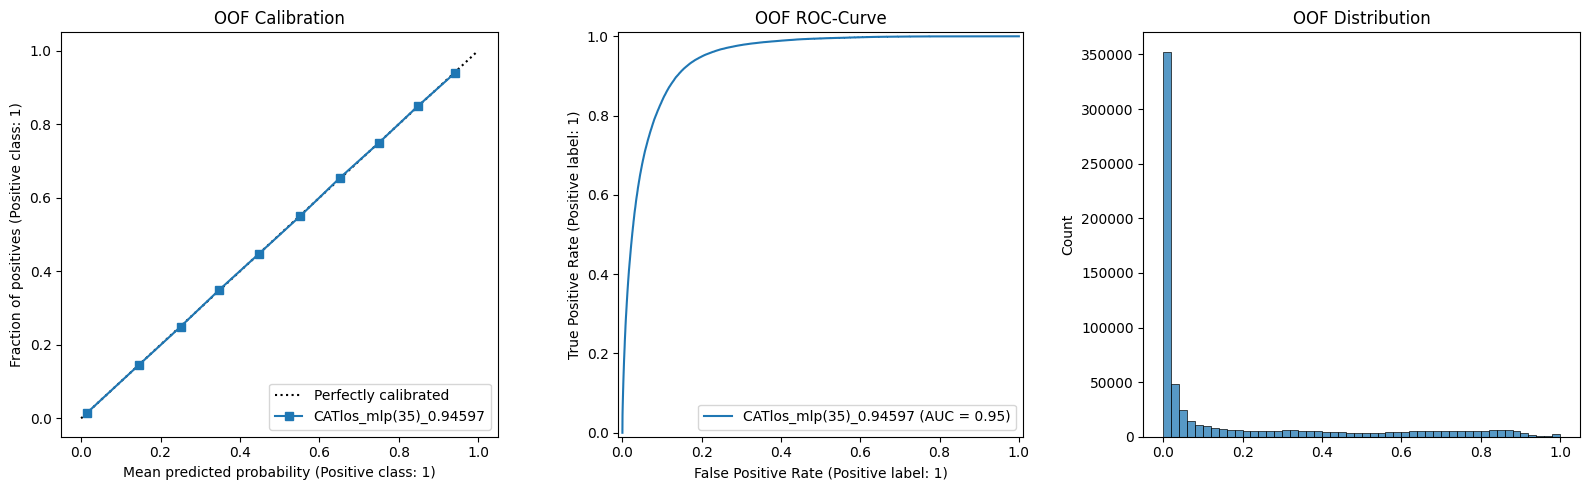

In [12]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y_1, oof_preds, n_bins=10, name=_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y_1, oof_preds, name=_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

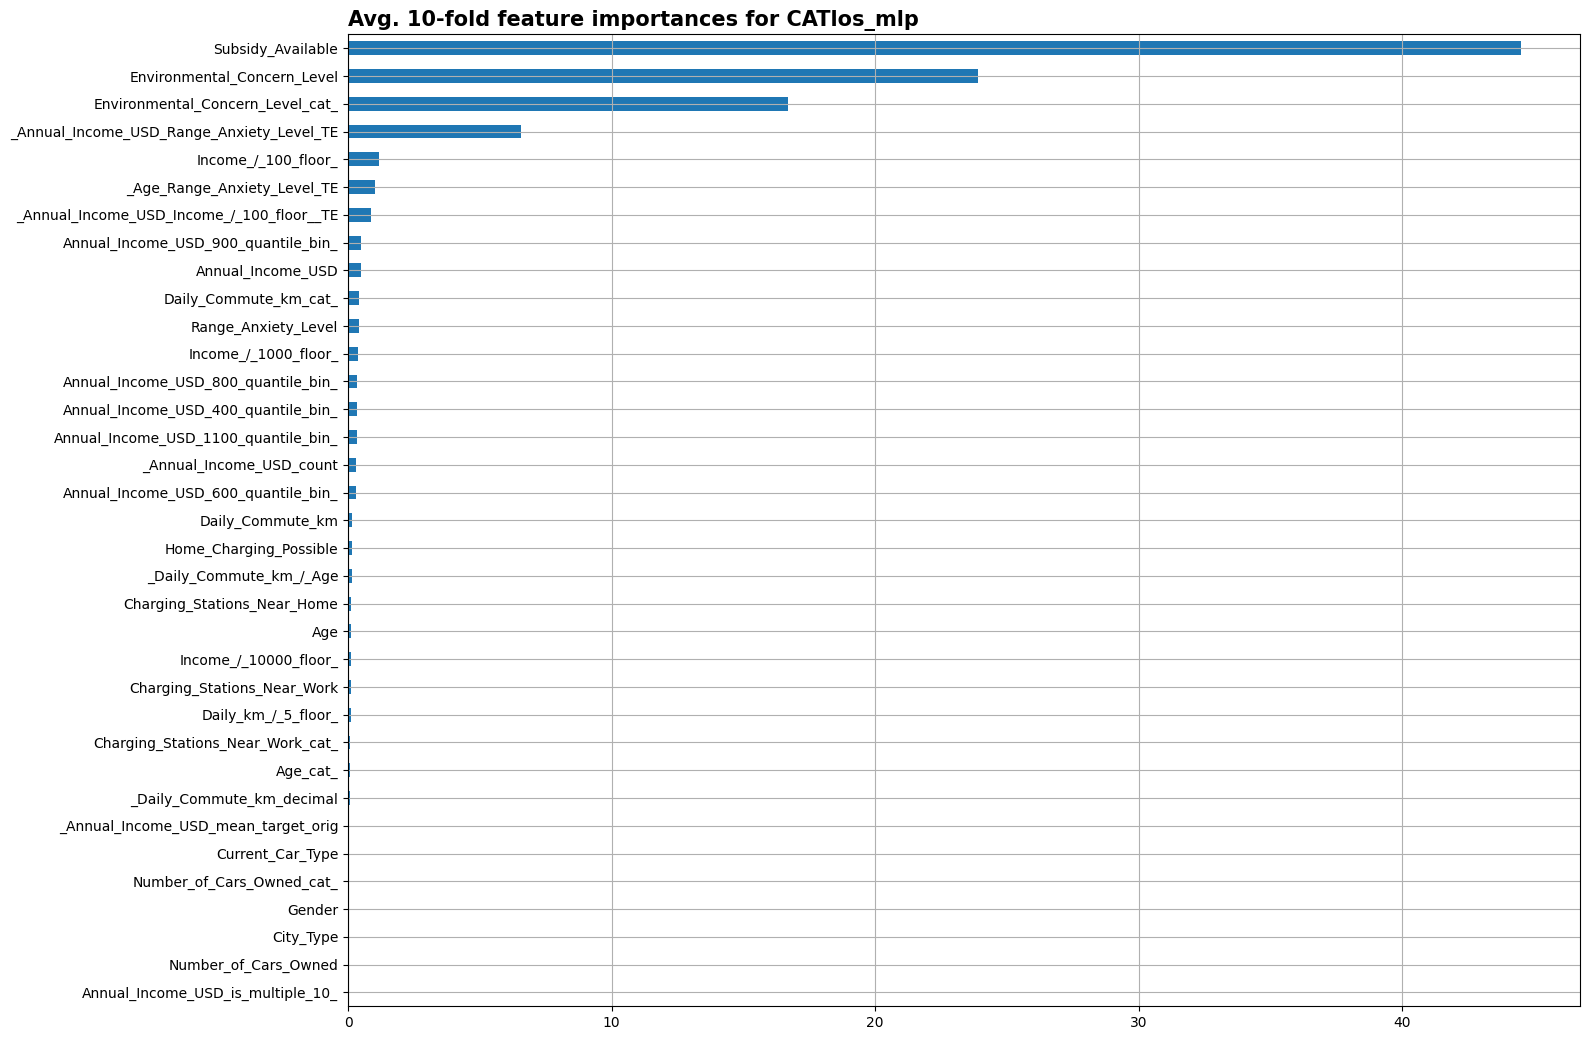

In [13]:
imp_df = pd.Series(np.mean(feat_importances, axis=0), index=X_tr.columns).sort_values()

plt.figure(figsize=(16, len(imp_df) * 0.3))
imp_df.plot.barh()
plt.title(f"Avg. {FOLDS}-fold feature importances for {MODEL_NAME}", loc='left', fontsize=15, fontweight='semibold')
plt.grid()
plt.tight_layout()
plt.show()

In [14]:
# !rm -r /kaggle/working/